cesta nalezena


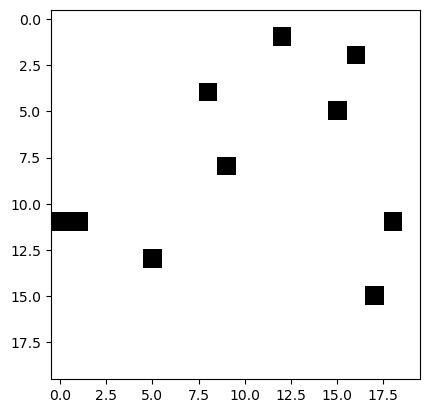

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

def nacti_data(nazev_souboru: str) -> np.ndarray:
    """
    Načte data ze souboru CSV a převede je na matici typu bool.

    Hodnoty 1 jsou převedeny na True,
    hodnoty 0 na False.

    Args:
        nazev_souboru: Cesta k CSV souboru.

    Returns:
        Dvourozměrné numpy pole typu bool.
    """
    soubor = np.genfromtxt(nazev_souboru, delimiter=",", dtype=int)
    matice = soubor.astype(bool)
    return matice

def obrazek_bludiste(zadana_matice: np.ndarray) -> None:
    """
    Vykreslí bludiště ve formě obrázku pomocí knihovny matplotlib.

    Hodnota False představuje průchodné pole,
    hodnota True zeď.

    Args:
        zadana_matice: Dvourozměrné numpy pole typu bool
            reprezentující bludiště.

    Returns:
        None
    """
    plt.imshow(zadana_matice, cmap='gray_r', origin='upper')

def zmena_policek(sablona: np.ndarray, pocet_zmen: int)-> np.ndarray:
    """
    
    Funkce vybere náhodné prvky v matici a změní jejich
    hodnotu z True na False nebo naopak.
    Tím vytvoří novou variantu bludiště.

    Args:
        sablona: Dvourozměrné numpy pole typu bool
            reprezentující bludiště.
        pocet_zmen: Počet políček, která mají být změněna.

    Returns:
        Upravená booleovská matice bludiště.
    """
    n = sablona.shape[0]
    for i in range(pocet_zmen):
        x, y = random.randint(0, n-1), random.randint(0, n-1)
        sablona[x,y] = not sablona[x,y]
    return sablona

def over_cestu(zadane_bludiste: np.ndarray) -> bool:
    """
    Ověřuje, jestli v bludišti existuje cesta z levého horního
    rohu do pravého dolního rohu.

    Funkce používá algoritmus BFS, False znamená volno.
    Nejdříve se do navstiveno a k_prohledani uloží 0,0 = levý horní roh. 
    Pak se ovří sousedé tohoto políčka a vybere se další volné. Oůvodní políčko se uloží jako předchůdce následujícího
    pro rekonstrukci cesty. set - zabrání duplikacím, deque pop.left - princip first in first out

    Pokud je cesta nalezena, bludiště se vykreslí.

    Args:
        zadane_bludiste: Dvourozměrné numpy pole typu bool
            reprezentující bludiště.

    Returns:
        True, pokud cesta existuje.
        False, pokud cesta neexistuje.
    """
    navstiveno = set()
    k_prohledani = deque()
    k_prohledani.append((0,0))
    navstiveno.add((0,0))
    n = zadane_bludiste.shape[0]
    predchudce = {}
    
    
    while k_prohledani:
        x, y = k_prohledani.popleft()            
        if x==n-1 and y==n-1:
            print("cesta nalezena")
            obrazek_bludiste(zadane_bludiste)
            return True
            
        smery = [(0,1), (1,0), (0,-1), (-1,0)]
        random.shuffle(smery)
        for dx, dy in smery:
            nx, ny = x+dx, y+dy
            if 0<=nx<n and 0<=ny<n and not zadane_bludiste[nx,ny] and (nx, ny) not in navstiveno:
                k_prohledani.append((nx, ny))
                navstiveno.add((nx, ny))
                predchudce[(nx, ny)] = (x, y)

    
    return False
        
nalezeno = False
bludiste = nacti_data("sablony/had.csv")
while not nalezeno:
    bludiste = nacti_data("sablony/prazdna.csv")
    zmena_policek(bludiste,10)
    nalezeno = over_cestu(bludiste)
        
       
            



